In [2]:
# Import libraries and load data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

# Handle missing values 
df = df.drop(columns=['Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [3]:
# Step 2 - Check data types of each column
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB
None


In [4]:
# Step 3 - Basic statistical summary
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [5]:
# Step 4 - Check missing values in each column
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing value percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing values per column:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Missing value percentage:
PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64


In [ ]:
# Step 5 - Visualize missing values
missing = df.isnull().sum()
ax = missing.plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)
for index, value in enumerate(missing):
    plt.text(index, value + 5, str(value), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Step 6 - Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Step 7 - Handle missing values

# Drop Cabin if it exists
df = df.drop(columns=['Cabin'], errors='ignore')

# Fill Age with median
# Median is better than mean when the data is skewed
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Check missing values after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


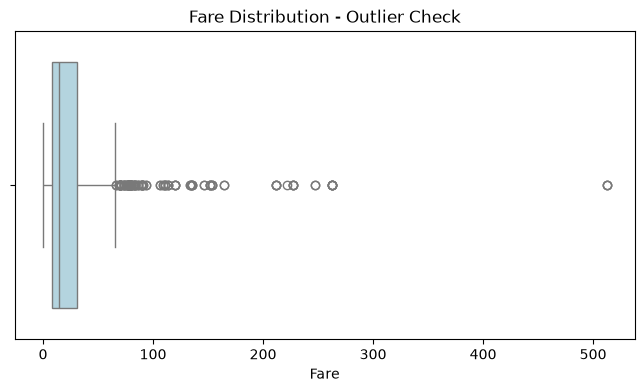

Fare Statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [12]:
# Step 8 - Check outliers using boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare'], color='lightblue')
plt.title('Fare Distribution - Outlier Check')
plt.show()
print("Fare Statistics:")
print(df['Fare'].describe())

In [13]:
# Step 9 - Drop columns not needed for analysis
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print("Columns remaining:", df.columns.tolist())
print("Final shape:", df.shape)

Columns remaining: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Final shape: (891, 8)


In [14]:
# Step 10 - Final check after all preprocessing
print("Final dataset info:")
print(df.info())
print("\nFinal missing values:")
print(df.isnull().sum())
print("\nFinal shape:", df.shape)
df.head()

Final dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None

Final missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Final shape: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [2]:
# SibSp - Count siblings/spouses aboard
sibsp_counts = df['SibSp'].value_counts().sort_index()
print("SibSp Counts:\n", sibsp_counts)

SibSp Counts:
 SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64


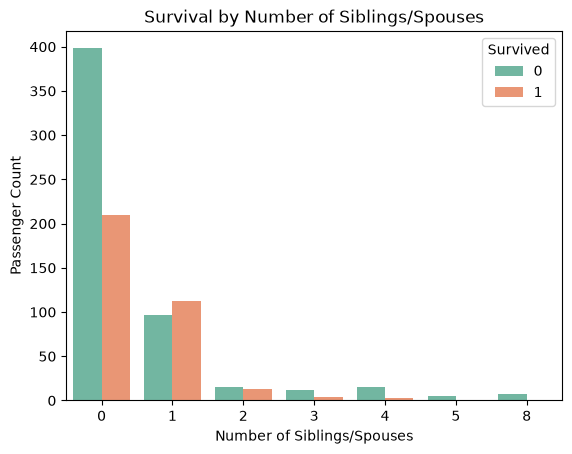

In [3]:
# Bar plot - Survival by SibSp
sns.countplot(x='SibSp', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Number of Siblings/Spouses')
plt.xlabel('Number of Siblings/Spouses')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [4]:
# Parch - Count parents/children aboard
parch_counts = df['Parch'].value_counts().sort_index()
print("Parch Counts:\n", parch_counts)

Parch Counts:
 Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64


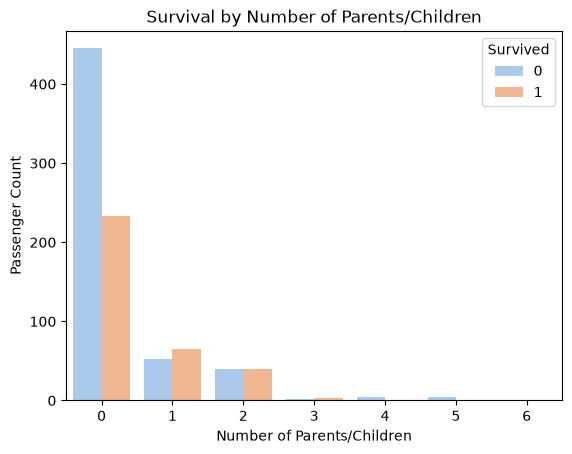

In [5]:
# Bar plot - Survival by Parch
sns.countplot(x='Parch', hue='Survived', data=df, palette='pastel')
plt.title('Survival by Number of Parents/Children')
plt.xlabel('Number of Parents/Children')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [6]:
# Fare statistics
print("Fare Statistics:")
print(df['Fare'].describe())

Fare Statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


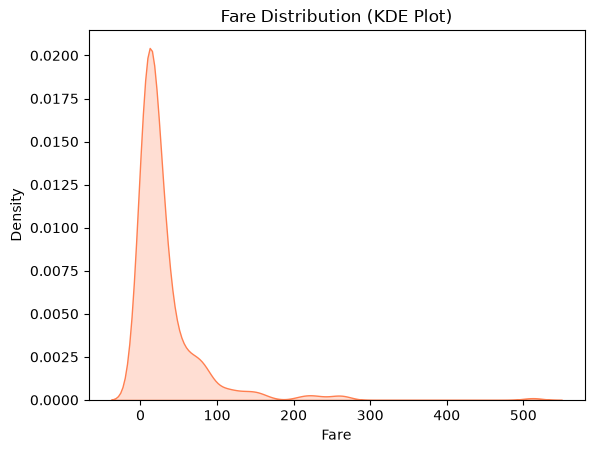

In [7]:
# KDE plot - Fare Distribution
sns.kdeplot(df['Fare'], fill=True, color='coral')
plt.title('Fare Distribution (KDE Plot)')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

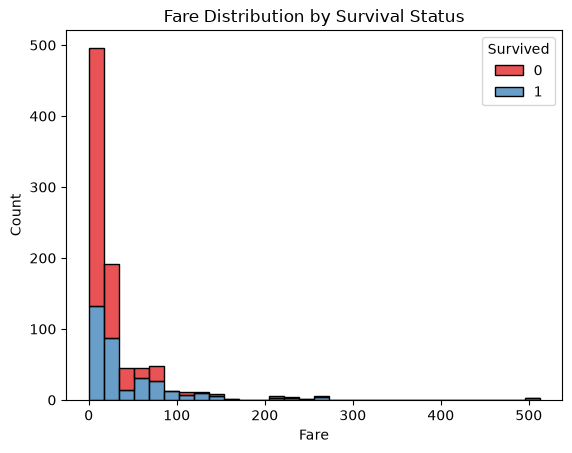

In [8]:
# Histogram - Fare by Survival
sns.histplot(data=df, x='Fare', hue='Survived', multiple='stack', bins=30, palette='Set1')
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

In [9]:
# Embarked - Count by port
embarked_counts = df['Embarked'].value_counts()
print("Embarked Counts:\n", embarked_counts)

Embarked Counts:
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


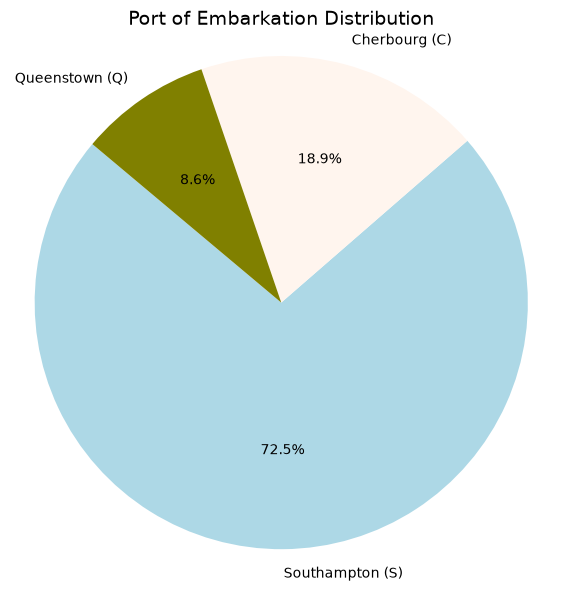

In [10]:
# Pie chart - Port distribution
labels = ['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)']
plt.figure(figsize=(7, 7))
plt.pie(embarked_counts, labels=labels, autopct='%1.1f%%',
        startangle=140, colors=['lightblue', 'seashell', 'olive'])
plt.title('Port of Embarkation Distribution', fontsize=14)
plt.axis('equal')
plt.show()

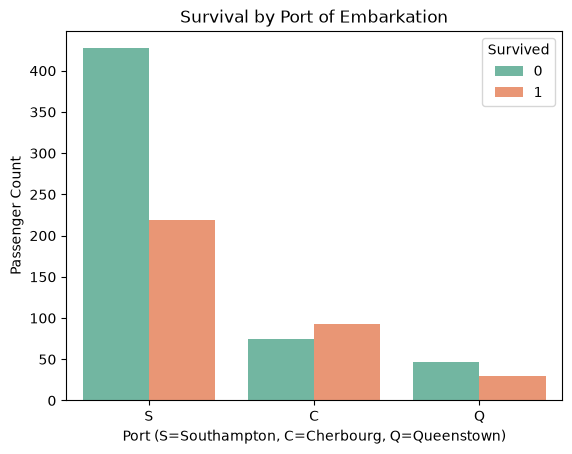

In [11]:
# Bar plot - Survival by Embarked
sns.countplot(x='Embarked', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Port of Embarkation')
plt.xlabel('Port (S=Southampton, C=Cherbourg, Q=Queenstown)')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()